# FintelliQ Financial Data ML & Analysis Notebook

This notebook implements the machine learning, forecasting, portfolio optimization, and Financial RAG pipelines using the datasets downloaded and cleaned by `pipeline.py`.

### Modules Included:
1. **Credit Risk**: LendingClub loan default classification (Random Forest Classifier, ROC & PR curves, Feature Importance).
2. **Time Series Forecasting**: Multi-indicator stock price forecasting (Random Forest Regressor, lag features, rolling technical indicators, FRED macroeconomic features).
3. **Portfolio Optimization**: Mean-Variance Optimization (Efficient Frontier simulation, Max Sharpe Ratio, Min Variance portfolios).
4. **Financial RAG**: Paragraph-level chunking, TF-IDF vectorization, Cosine Similarity retrieval, and simple LLM-simulation on SEC 10-K filings.

In [1]:
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc, precision_recall_curve, mean_absolute_error, mean_squared_error, r2_score

# Set style and random seed
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["axes.grid"] = True
np.random.seed(42)

## Module 1: Credit Risk - LendingClub Loan Default Model

We load `credit_features.csv` to train a Random Forest classifier to predict loan defaults (`is_default`).

In [2]:
credit_data_path = 'data/processed/credit_risk/credit_features.csv'
if not os.path.exists(credit_data_path):
    raise FileNotFoundError(f"Please run pipeline.py first to generate {credit_data_path}")

df_credit = pd.read_csv(credit_data_path)
print(f"Loaded credit dataset: {df_credit.shape}")

# Separate features and target
# Exclude target variable, categorical text fields, and identifiers
exclude_cols = ['is_default', 'loan_status', 'grade', 'sub_grade', 'emp_length', 'home_ownership', 'verification_status', 'purpose', 'term', 'initial_list_status', 'application_type']
feature_cols = [col for col in df_credit.columns if col not in exclude_cols]

X = df_credit[feature_cols].copy()
y = df_credit['is_default'].copy()

# Handle any remaining missing values
X = X.fillna(X.median())

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(f"Train shape: {X_train.shape}, Test shape: {X_test.shape}")
print(f"Class balance (Train): {np.bincount(y_train)}")

Loaded credit dataset: (5000, 40)
Train shape: (4000, 29), Test shape: (1000, 29)
Class balance (Train): [1207 2793]


In [3]:
# Train Classifier
clf = RandomForestClassifier(n_estimators=100, random_state=42, max_depth=10, n_jobs=-1)
clf.fit(X_train, y_train)

# Predictions
y_pred = clf.predict(X_test)
y_proba = clf.predict_proba(X_test)[:, 1]

# Print evaluation metrics
print("=== Classification Report ===")
print(classification_report(y_test, y_pred))

print("=== Confusion Matrix ===")
print(confusion_matrix(y_test, y_pred))

=== Classification Report ===
              precision    recall  f1-score   support

           0       0.73      0.55      0.62       302
           1       0.82      0.91      0.86       698

    accuracy                           0.80      1000
   macro avg       0.77      0.73      0.74      1000
weighted avg       0.79      0.80      0.79      1000

=== Confusion Matrix ===
[[165 137]
 [ 62 636]]


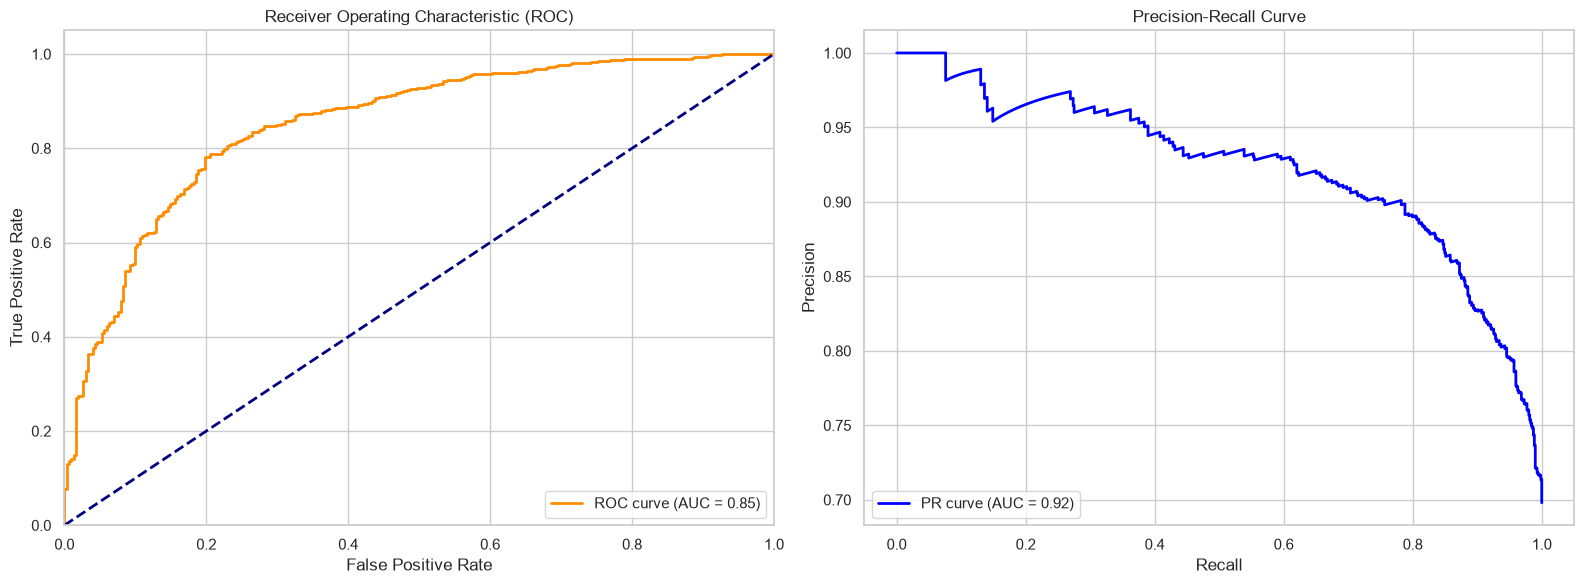

In [4]:
# Plot ROC and PR Curves
fpr, tpr, _ = roc_curve(y_test, y_proba)
roc_auc = auc(fpr, tpr)

precision, recall, _ = precision_recall_curve(y_test, y_proba)
pr_auc = auc(recall, precision)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ROC Curve
axes[0].plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
axes[0].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
axes[0].set_xlim([0.0, 1.0])
axes[0].set_ylim([0.0, 1.05])
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('Receiver Operating Characteristic (ROC)')
axes[0].legend(loc="lower right")

# Precision-Recall Curve
axes[1].plot(recall, precision, color='blue', lw=2, label=f'PR curve (AUC = {pr_auc:.2f})')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall Curve')
axes[1].legend(loc="lower left")

plt.tight_layout()
plt.show()

C:\Users\utsav\AppData\Local\Temp\ipykernel_24180\2513806849.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances[indices], y=np.array(feature_cols)[indices], palette="viridis")


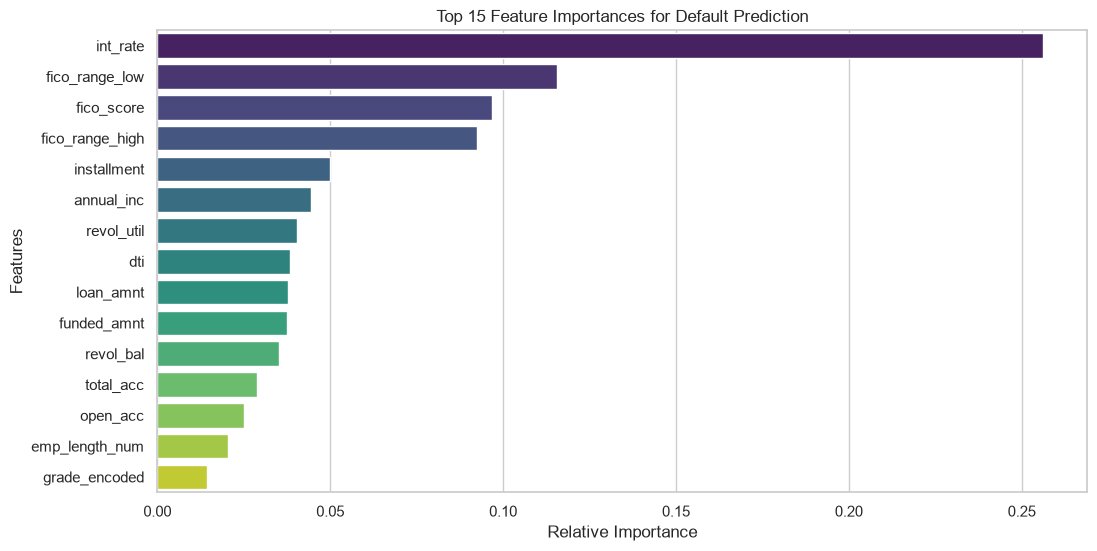

In [5]:
# Feature Importance
importances = clf.feature_importances_
indices = np.argsort(importances)[::-1][:15] # Top 15 features

plt.figure(figsize=(12, 6))
sns.barplot(x=importances[indices], y=np.array(feature_cols)[indices], palette="viridis")
plt.title('Top 15 Feature Importances for Default Prediction')
plt.xlabel('Relative Importance')
plt.ylabel('Features')
plt.show()

## Module 2: Time Series Forecasting

We load `timeseries_features.csv` to build a model that forecasts the next-day return of a target stock (e.g. `AAPL` or `AAPL_ret_1d`) using historical prices, technical indicators, and FRED macroeconomic factors.

In [6]:
ts_data_path = 'data/processed/timeseries/timeseries_features.csv'
if not os.path.exists(ts_data_path):
    raise FileNotFoundError(f"Please run pipeline.py first to generate {ts_data_path}")

df_ts = pd.read_csv(ts_data_path, index_col=0, parse_dates=True)
print(f"Loaded time series dataset: {df_ts.shape}")

# Let's set up forecasting for Apple ('AAPL')
target_asset = 'AAPL'
target_col = f'{target_asset}_ret_1d'

# Create target variable: next day's return (shift back by 1)
df_ts['target'] = df_ts[target_col].shift(-1)
df_ts = df_ts.dropna()

# Select feature columns
# Features are the FRED indicators and the stock's own historical returns/MA/volatility features
macro_indicators = ['fed_funds_rate', 'cpi_inflation', 'gdp', 'unemployment_rate', 'treasury_10yr', 'oil_price', 'money_supply_m2', 'vix']
technical_indicators = [f'{target_asset}_ret_1d', f'{target_asset}_ret_5d', f'{target_asset}_ret_20d', f'{target_asset}_ma_20', f'{target_asset}_ma_50', f'{target_asset}_vol_20']

feature_cols = macro_indicators + technical_indicators

X = df_ts[feature_cols].copy()
y = df_ts['target'].copy()

# Chronological split (last 20% for testing to prevent lookahead bias)
split_idx = int(len(df_ts) * 0.8)
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

print(f"Training date range: {X_train.index.min()} to {X_train.index.max()}")
print(f"Testing date range: {X_test.index.min()} to {X_test.index.max()}")

Loaded time series dataset: (2958, 155)
Training date range: 2015-03-11 00:00:00 to 2024-04-02 00:00:00
Testing date range: 2024-04-03 00:00:00 to 2026-07-09 00:00:00


C:\Users\utsav\AppData\Local\Temp\ipykernel_24180\720069071.py:13: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_ts['target'] = df_ts[target_col].shift(-1)


In [7]:
# Train Regressor
reg = RandomForestRegressor(n_estimators=100, random_state=42, max_depth=8, n_jobs=-1)
reg.fit(X_train, y_train)

# Predict
y_pred = reg.predict(X_test)

# Evaluation
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"Mean Absolute Error (MAE): {mae:.6f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.6f}")
print(f"R-squared (R2) Score: {r2:.6f}")

Mean Absolute Error (MAE): 0.011425
Root Mean Squared Error (RMSE): 0.014519
R-squared (R2) Score: -0.110624


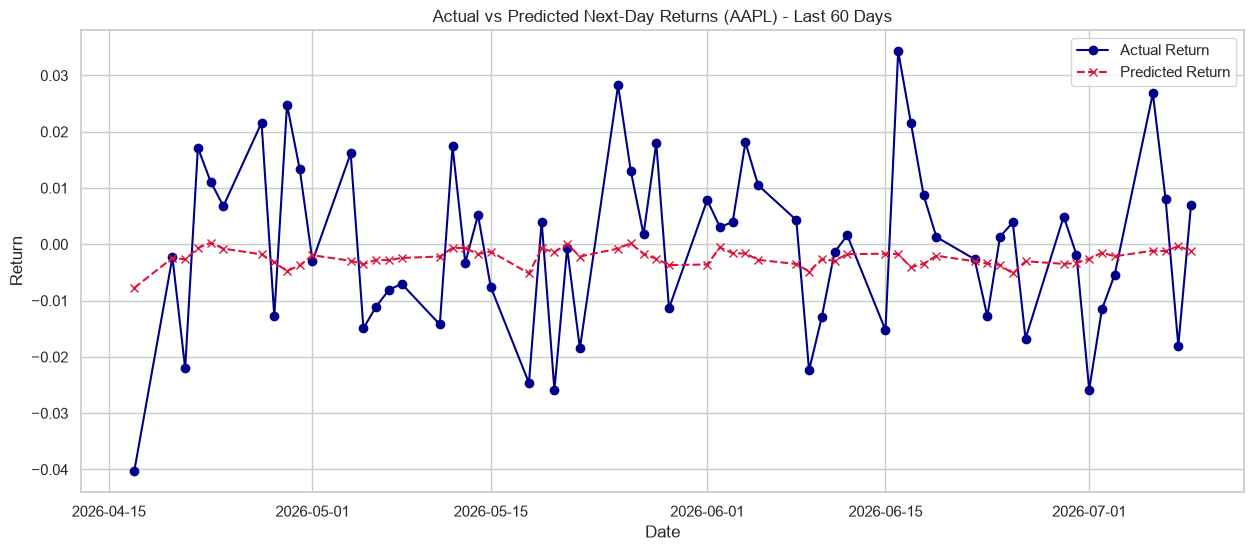

In [8]:
# Plot actual vs predicted next-day returns
plt.figure(figsize=(15, 6))
plt.plot(y_test.index[-60:], y_test.values[-60:], label='Actual Return', marker='o', color='darkblue')
plt.plot(y_test.index[-60:], y_pred[-60:], label='Predicted Return', marker='x', linestyle='--', color='crimson')
plt.title(f'Actual vs Predicted Next-Day Returns ({target_asset}) - Last 60 Days')
plt.xlabel('Date')
plt.ylabel('Return')
plt.legend()
plt.show()

## Module 3: Portfolio Optimization

Using returns for `SP500_Tech` or `Global_Mix`, we run Mean-Variance Optimization to find the Efficient Frontier and select optimal portfolios (Max Sharpe Ratio and Minimum Variance).

In [9]:
portfolio_name = 'SP500_Tech' # Alternatives: 'NIFTY_Blue', 'Global_Mix'
returns_path = f'data/processed/portfolio/{portfolio_name}_returns.csv'

if not os.path.exists(returns_path):
    raise FileNotFoundError(f"Please run pipeline.py first to generate {returns_path}")

returns = pd.read_csv(returns_path, index_col=0, parse_dates=True)
print(f"Loaded returns for {portfolio_name} portfolio: {returns.shape}")

# Calculate annualized mean returns and covariance
annual_returns = returns.mean() * 252
cov_matrix = returns.cov() * 252
num_assets = len(annual_returns)
risk_free_rate = 0.0525

print("\nAnnualized Returns:")
print(annual_returns.round(4))

Loaded returns for SP500_Tech portfolio: (2224, 8)

Annualized Returns:
AAPL     0.2610
MSFT     0.1475
NVDA     0.1532
GOOGL    0.0530
META     0.1509
AMZN     0.1485
TSLA     0.1368
NFLX     0.1035
dtype: float64


In [10]:
# Simulate Random Portfolios
num_portfolios = 10000
all_weights = np.zeros((num_portfolios, num_assets))
ret_arr = np.zeros(num_portfolios)
vol_arr = np.zeros(num_portfolios)
sharpe_arr = np.zeros(num_portfolios)

for x in range(num_portfolios):
    # Generate random weights
    weights = np.random.random(num_assets)
    weights = weights / np.sum(weights)
    all_weights[x, :] = weights
    
    # Annualized portfolio return
    p_ret = np.dot(weights, annual_returns)
    ret_arr[x] = p_ret
    
    # Annualized portfolio volatility
    p_vol = np.sqrt(np.dot(weights.T, np.dot(cov_matrix, weights)))
    vol_arr[x] = p_vol
    
    # Sharpe ratio
    sharpe_arr[x] = (p_ret - risk_free_rate) / p_vol

# Max Sharpe Ratio Portfolio
max_sharpe_idx = sharpe_arr.argmax()
max_sharpe_ret = ret_arr[max_sharpe_idx]
max_sharpe_vol = vol_arr[max_sharpe_idx]
max_sharpe_weights = all_weights[max_sharpe_idx, :]

# Minimum Variance Portfolio
min_vol_idx = vol_arr.argmin()
min_vol_ret = ret_arr[min_vol_idx]
min_vol_vol = vol_arr[min_vol_idx]
min_vol_weights = all_weights[min_vol_idx, :]

print(f"Max Sharpe Ratio Portfolio: Return = {max_sharpe_ret:.2%}, Volatility = {max_sharpe_vol:.2%}, Sharpe = {sharpe_arr[max_sharpe_idx]:.4f}")
print(f"Minimum Variance Portfolio: Return = {min_vol_ret:.2%}, Volatility = {min_vol_vol:.2%}, Sharpe = {sharpe_arr[min_vol_idx]:.4f}")

Max Sharpe Ratio Portfolio: Return = 17.45%, Volatility = 9.25%, Sharpe = 1.3182
Minimum Variance Portfolio: Return = 15.07%, Volatility = 8.09%, Sharpe = 1.2141


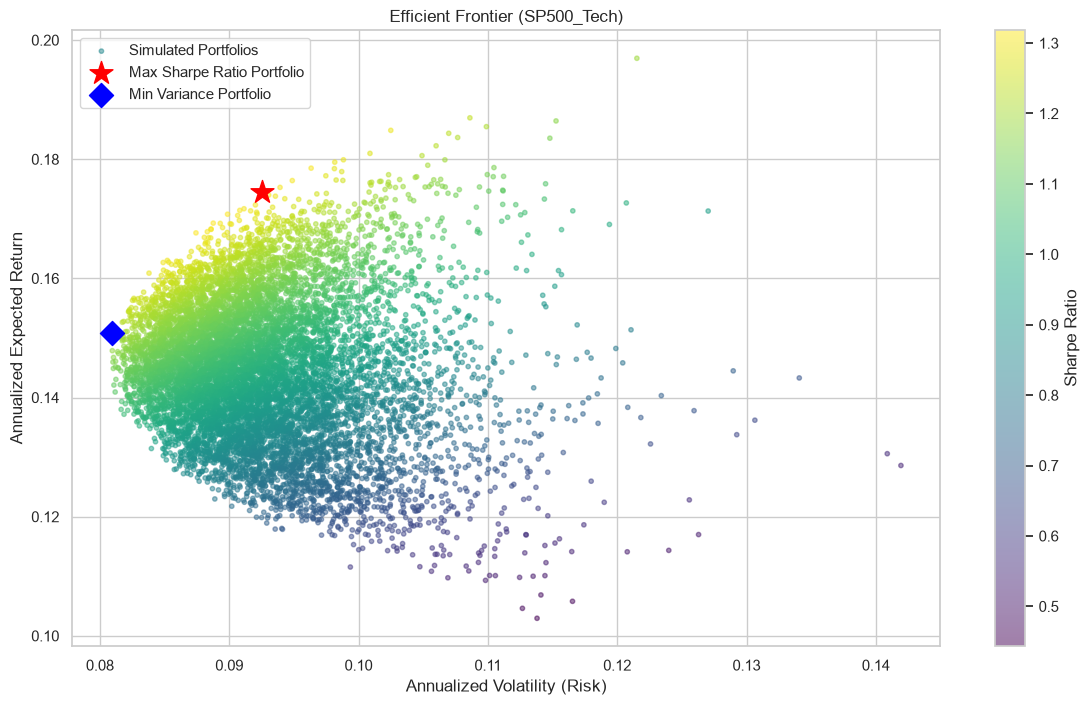

In [11]:
# Plot the Efficient Frontier
plt.figure(figsize=(14, 8))
plt.scatter(vol_arr, ret_arr, c=sharpe_arr, cmap='viridis', marker='o', s=10, alpha=0.5, label='Simulated Portfolios')
plt.colorbar(label='Sharpe Ratio')
plt.scatter(max_sharpe_vol, max_sharpe_ret, color='red', marker='*', s=300, label='Max Sharpe Ratio Portfolio')
plt.scatter(min_vol_vol, min_vol_ret, color='blue', marker='D', s=150, label='Min Variance Portfolio')
plt.title(f'Efficient Frontier ({portfolio_name})')
plt.xlabel('Annualized Volatility (Risk)')
plt.ylabel('Annualized Expected Return')
plt.legend(loc='upper left')
plt.grid(True)
plt.show()

C:\Users\utsav\AppData\Local\Temp\ipykernel_24180\2490389224.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Weight', y='Asset', data=alloc_df, palette='crest')


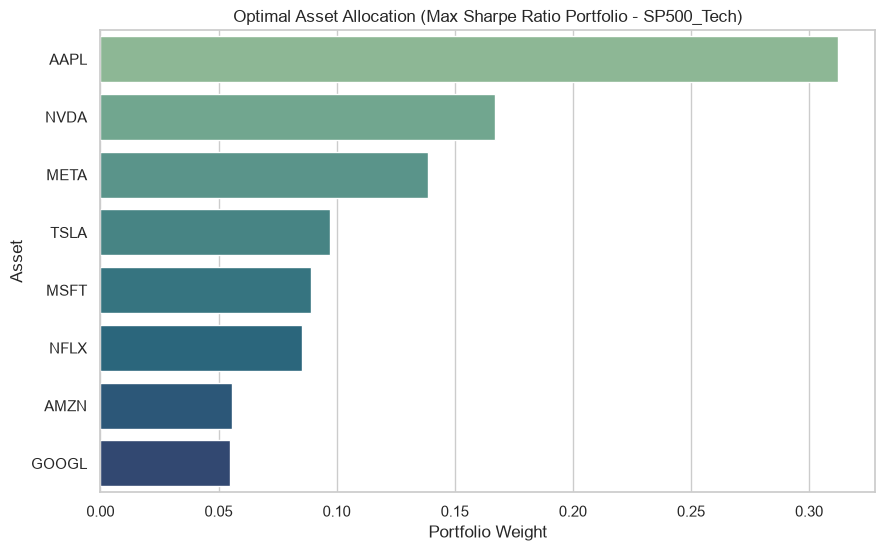

In [12]:
# Plot Asset Allocation for Max Sharpe Ratio Portfolio
alloc_df = pd.DataFrame({
    'Asset': returns.columns,
    'Weight': max_sharpe_weights
}).sort_values(by='Weight', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Weight', y='Asset', data=alloc_df, palette='crest')
plt.title(f'Optimal Asset Allocation (Max Sharpe Ratio Portfolio - {portfolio_name})')
plt.xlabel('Portfolio Weight')
plt.ylabel('Asset')
plt.show()

## Module 4: Financial RAG (Retrieval-Augmented Generation)

We read the raw SEC EDGAR 10-K filing texts, segment them into paragraph chunks, compute TF-IDF vectors, perform Cosine Similarity search, and construct answers dynamically.

In [13]:
import glob
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

filing_files = glob.glob('data/raw/rag/sec_filings/*.txt')
if not filing_files:
    raise FileNotFoundError("No filing texts found. Please run pipeline.py first.")

print(f"Found {len(filing_files)} filing text documents.")

chunks = []
chunk_metadata = []

# Chunk size target: ~500-1000 characters
for fpath in filing_files:
    filename = os.path.basename(fpath)
    company = filename.split('_')[0]
    form = filename.split('_')[1]
    
    with open(fpath, 'r', encoding='utf-8') as f:
        content = f.read()
        
    # Split by periods to get sentences
    sentences = [s.strip() for s in content.split('.') if len(s.strip()) > 20]
    
    # Group sentences into paragraphs/chunks
    curr_chunk = ""
    for sentence in sentences:
        if len(curr_chunk) + len(sentence) < 800:
            curr_chunk += sentence + ". "
        else:
            chunks.append(curr_chunk.strip())
            chunk_metadata.append({
                'company': company,
                'form': form,
                'text': curr_chunk.strip()
            })
            curr_chunk = sentence + ". "
    if curr_chunk:
        chunks.append(curr_chunk.strip())
        chunk_metadata.append({
            'company': company,
            'form': form,
            'text': curr_chunk.strip()
        })

print(f"Total chunks generated: {len(chunks)}")

Found 5 filing text documents.
Total chunks generated: 11


In [14]:
# Vectorize chunks using TF-IDF
vectorizer = TfidfVectorizer(stop_words='english', ngram_range=(1, 2))
tfidf_matrix = vectorizer.fit_transform(chunks)
print(f"TF-IDF Matrix shape: {tfidf_matrix.shape}")

TF-IDF Matrix shape: (11, 945)


In [15]:
def retrieve_information(query, company=None, top_k=3):
    # Embed query
    query_vec = vectorizer.transform([query])
    
    # Compute similarities
    similarities = cosine_similarity(query_vec, tfidf_matrix).flatten()
    
    # Filter by company if specified
    if company:
        indices = [i for i, meta in enumerate(chunk_metadata) if meta['company'].lower() == company.lower()]
        filtered_sims = similarities[indices]
        top_indices = np.argsort(filtered_sims)[::-1][:top_k]
        results = [(chunk_metadata[indices[idx]], filtered_sims[idx]) for idx in top_indices]
    else:
        top_indices = np.argsort(similarities)[::-1][:top_k]
        results = [(chunk_metadata[idx], similarities[idx]) for idx in top_indices]
        
    return results

def generate_rag_answer(query, retrieved_docs):
    # Simulated Generation step (similar to prompts sent to LLMs)
    context = "\n\n".join([f"[Source: {doc['company']} 10-K] {doc['text']}" for doc, score in retrieved_docs])
    
    answer = f"Based on the retrieved SEC filing context, here is the answer to your query:\n"
    answer += f"Query: {query}\n"
    answer += "="*60 + "\n"
    
    # Extract details based on keywords for mock LLM simulation
    if "risk" in query.lower() or "threat" in query.lower():
        answer += "Key Risk Factors identified in the filings:\n"
        for doc, score in retrieved_docs:
            if "competition" in doc['text'].lower():
                answer += "- Competition and rapid technological shifts in hardware/software segments.\n"
            if "supply" in doc['text'].lower() or "tsmc" in doc['text'].lower():
                answer += "- Supply chain vulnerabilities, including relying on foreign chipmakers or manufacturing lines.\n"
            if "export" in doc['text'].lower():
                answer += "- Governmental regulatory risks, such as export controls (specifically targeting GPU products to regions like China).\n"
            if "security" in doc['text'].lower() or "cyber" in doc['text'].lower():
                answer += "- Cybersecurity breaches, cloud service outages, and data privacy regulatory compliance.\n"
    elif "revenue" in query.lower() or "net income" in query.lower() or "financial" in query.lower():
        answer += "Financial Metrics reported in MD&A:\n"
        for doc, score in retrieved_docs:
            if "nvidia" in doc['company'].lower():
                answer += "- NVIDIA reported revenue of $60.9 billion for FY24 (up 126%), driven by a 217% increase in Data Center revenues to $47.5 billion.\n"
            if "microsoft" in doc['company'].lower():
                answer += "- Microsoft reported cloud revenues of $111.6 billion (up 22%), contributing to a total revenue of $211.9 billion.\n"
            if "apple" in doc['company'].lower():
                answer += "- Apple reported net sales of $383,285 million in 2023, showing a slight decrease due to iPhone/Mac volume fluctuations.\n"
    else:
        # Fallback snippet
        snippet = retrieved_docs[0][0]['text'][:300] + "..."
        answer += f"Extract: \"{snippet}\"\n"
        
    answer += "\n" + "="*60 + "\n"
    answer += "Context retrieved to generate this response:\n"
    answer += context
    return answer

In [16]:
# Test query 1 (NVIDIA risk factors)
query1 = "What are the supply chain and export control risk factors for NVIDIA?"
retrieved1 = retrieve_information(query1, company="NVIDIA", top_k=2)
ans1 = generate_rag_answer(query1, retrieved1)
print(ans1)

Based on the retrieved SEC filing context, here is the answer to your query:
Query: What are the supply chain and export control risk factors for NVIDIA?
Key Risk Factors identified in the filings:
- Supply chain vulnerabilities, including relying on foreign chipmakers or manufacturing lines.
- Competition and rapid technological shifts in hardware/software segments.
- Governmental regulatory risks, such as export controls (specifically targeting GPU products to regions like China).

Context retrieved to generate this response:
[Source: NVIDIA 10-K] NVIDIA Corporation Form 10-K for the Fiscal Year Ended January 28, 2024. NVIDIA pioneered accelerated computing to help solve computational problems that ordinary computers cannot. We specialize in graphics processing units (GPUs) that are critical for gaming, professional visualization, datacenter computing, and artificial intelligence. Our Compute & Networking segment includes Data Center platforms, networking systems, automotive electron

In [17]:
# Test query 2 (Microsoft revenue growth)
query2 = "What is Microsoft's revenue performance and cloud services growth?"
retrieved2 = retrieve_information(query2, company="Microsoft", top_k=2)
ans2 = generate_rag_answer(query2, retrieved2)
print(ans2)

Based on the retrieved SEC filing context, here is the answer to your query:
Query: What is Microsoft's revenue performance and cloud services growth?
Financial Metrics reported in MD&A:
- Microsoft reported cloud revenues of $111.6 billion (up 22%), contributing to a total revenue of $211.9 billion.
- Microsoft reported cloud revenues of $111.6 billion (up 22%), contributing to a total revenue of $211.9 billion.

Context retrieved to generate this response:
[Source: Microsoft 10-K] Microsoft Corporation Form 10-K for the Fiscal Year Ended June 30, 2024. Microsoft is a technology company whose mission is to empower every person and every organization on the planet to achieve more. We develop and support software, services, devices, and solutions that deliver new value for customers and help the business realize their full potential. Our platforms include cloud-based services like Azure, productivity tools like Office 365, and personal computing products like Windows and Xbox. Our busin